In [2]:
import numpy as np
from keras.datasets import mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout, MaxPooling2D
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
def plot_mnist_samples(X_train, y_train, num_samples=3):
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
        plt.title(f"Label: {y_train[i]}")
        plt.axis('off')
    plt.show()



**Small CNN**

In [3]:
def get_data_mnist():
    # Load dataset
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    # Reshape
    X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
    X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')


    # One-hot encode outputs
    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)
    num_classes = y_test.shape[1]

    return (X_train, y_train), (X_test, y_test), num_classes

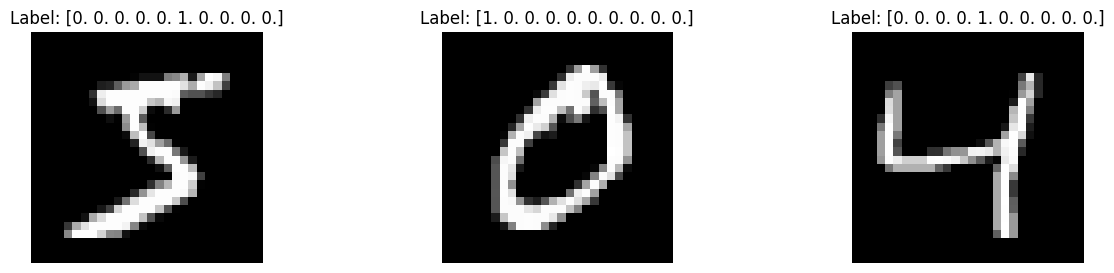

In [6]:
(X_train, y_train), _, _ = get_data_mnist()
plot_mnist_samples(X_train, y_train)

In [17]:
def small_model(num_classes):
    # Create model
    model = Sequential()
    model.add(Conv2D(64, (3, 3), input_shape=(28, 28, 1), activation='relu'))
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(Flatten())
    model.add(Dense(num_classes, activation='softmax'))

    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

In [8]:
(X_train, y_train), (X_test, y_test), num_classes = get_data_mnist()
model = small_model(num_classes)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
300/300 - 161s - 535ms/step - accuracy: 0.9373 - loss: 0.5718 - val_accuracy: 0.9734 - val_loss: 0.0826
Epoch 2/10
300/300 - 174s - 581ms/step - accuracy: 0.9826 - loss: 0.0579 - val_accuracy: 0.9789 - val_loss: 0.0703
Epoch 3/10
300/300 - 165s - 550ms/step - accuracy: 0.9875 - loss: 0.0387 - val_accuracy: 0.9763 - val_loss: 0.0829
Epoch 4/10
300/300 - 206s - 688ms/step - accuracy: 0.9916 - loss: 0.0250 - val_accuracy: 0.9747 - val_loss: 0.1022
Epoch 5/10
300/300 - 196s - 655ms/step - accuracy: 0.9924 - loss: 0.0246 - val_accuracy: 0.9757 - val_loss: 0.1049
Epoch 6/10
300/300 - 209s - 696ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9779 - val_loss: 0.1057
Epoch 7/10
300/300 - 168s - 562ms/step - accuracy: 0.9948 - loss: 0.0156 - val_accuracy: 0.9751 - val_loss: 0.1206
Epoch 8/10
300/300 - 207s - 690ms/step - accuracy: 0.9943 - loss: 0.0171 - val_accuracy: 0.9765 - val_loss: 0.1126
Epoch 9/10
300/300 - 191s - 637ms/step - accuracy: 0.9954 - loss: 0.0141 - val_a

In [3]:
def print_model_error_rate(model, X_test, y_test):
    # Final evaluation of the model
    scores = model.evaluate(X_test, y_test, verbose=0)
    print("Model score : %.2f%%" % (scores[1]*100))
    print("Model error rate : %.2f%%" % (100 - scores[1]*100))


In [6]:
print_model_error_rate(model, X_test, y_test)


Model score : 98.60%
Model error rate : 1.40%


**Small CNN with Data Normalization**

In [18]:
def get_data_mnist():
    np_utils = tf.keras.utils
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255.0
    X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255.0

    y_train = np_utils.to_categorical(y_train)
    y_test = np_utils.to_categorical(y_test)
    num_classes = y_test.shape[1]

    return (X_train, y_train), (X_test, y_test), num_classes


In [19]:
(X_train, y_train), (X_test, y_test), num_classes = get_data_mnist()
model = small_model(num_classes)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)





Epoch 1/10
300/300 - 168s - 562ms/step - accuracy: 0.9392 - loss: 0.2170 - val_accuracy: 0.9804 - val_loss: 0.0634
Epoch 2/10
300/300 - 155s - 518ms/step - accuracy: 0.9813 - loss: 0.0615 - val_accuracy: 0.9823 - val_loss: 0.0548
Epoch 3/10
300/300 - 203s - 676ms/step - accuracy: 0.9863 - loss: 0.0451 - val_accuracy: 0.9846 - val_loss: 0.0466
Epoch 4/10
300/300 - 205s - 685ms/step - accuracy: 0.9901 - loss: 0.0333 - val_accuracy: 0.9855 - val_loss: 0.0453
Epoch 5/10
300/300 - 160s - 532ms/step - accuracy: 0.9919 - loss: 0.0259 - val_accuracy: 0.9866 - val_loss: 0.0468
Epoch 6/10
300/300 - 203s - 677ms/step - accuracy: 0.9941 - loss: 0.0195 - val_accuracy: 0.9861 - val_loss: 0.0466
Epoch 7/10
300/300 - 161s - 535ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.9855 - val_loss: 0.0504
Epoch 8/10
300/300 - 201s - 669ms/step - accuracy: 0.9956 - loss: 0.0133 - val_accuracy: 0.9836 - val_loss: 0.0651
Epoch 9/10
300/300 - 201s - 672ms/step - accuracy: 0.9969 - loss: 0.0098 - val_a

In [20]:
print_model_error_rate(model, X_test, y_test)

Model score : 98.56%
Model error rate : 1.44%


**Meduim CNN**

In [9]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

def medium_model(num_classes):
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(32, (5, 5), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


(X_train, y_train), (X_test, y_test), num_classes = get_data_mnist()
# build the model
mediumModel = medium_model(num_classes)
# Fit the model
medium_history=mediumModel.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200)
# evaluation :
print_model_error_rate(mediumModel, X_test, y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - accuracy: 0.8545 - loss: 0.5044 - val_accuracy: 0.9752 - val_loss: 0.0814
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.9754 - loss: 0.0825 - val_accuracy: 0.9795 - val_loss: 0.0608
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 109ms/step - accuracy: 0.9828 - loss: 0.0572 - val_accuracy: 0.9821 - val_loss: 0.0547
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 31s 104ms/step - accuracy: 0.9857 - loss: 0.0452 - val_accuracy: 0.9867 - val_loss: 0.0391
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9881 - loss: 0.0362 - val_accuracy: 0.9886 - val_loss: 0.0358
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - accuracy: 0.9918 - loss: 0.0260 - val_accuracy: 0.9888 - val_loss: 0.0318
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.9927 - loss: 0.0225 - val_accuracy: 0.9892 - val_loss: 0.0349
Epoch 8/10
300/300 ━━━━━━━━━━━━━

**Large CNN**

In [11]:
def large_model(num_classes):
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))  # Proper input shape
    model.add(Conv2D(30, (5, 5), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(15, (3, 3), activation='relu'))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

(X_train, y_train), (X_test, y_test), num_classes = get_data_mnist()
largeModel = large_model(num_classes)
# Fit the model
large_history=largeModel.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200)
# evaluation :
print_model_error_rate(largeModel, X_test, y_test)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.8150 - loss: 0.6296 - val_accuracy: 0.9776 - val_loss: 0.0757
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 39s 120ms/step - accuracy: 0.9754 - loss: 0.0794 - val_accuracy: 0.9849 - val_loss: 0.0442
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 39s 130ms/step - accuracy: 0.9833 - loss: 0.0536 - val_accuracy: 0.9891 - val_loss: 0.0342
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.9878 - loss: 0.0396 - val_accuracy: 0.9870 - val_loss: 0.0447
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - accuracy: 0.9903 - loss: 0.0336 - val_accuracy: 0.9899 - val_loss: 0.0347
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 128ms/step - accuracy: 0.9914 - loss: 0.0271 - val_accuracy: 0.9901 - val_loss: 0.0330
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 124ms/step - accuracy: 0.9927 - loss: 0.0227 - val_accuracy: 0.9897 - val_loss: 0.0300
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - accuracy: 0.9935 - loss: 0

**Sauvegarde et chargements des modèles Keras :**

In [21]:
from keras.models import model_from_json

# This function saves a model on the drive using two files: a json and a h5
def save_keras_model(model, filename):
    # serialize model to JSON
    model_json = model.to_json()
    with open(filename + ".json", "w") as json_file:
        json_file.write(model_json)
    # serialize weights to HDF5
    model.save_weights(filename + ".weights.h5")
    print("model "+filename+" saved successfully ! ")


In [22]:
save_keras_model(model, "small_CNN")
save_keras_model(mediumModel, "medium_CNN")
save_keras_model(largeModel, "large_CNN")


model small_CNN saved successfully ! 
model medium_CNN saved successfully ! 
model large_CNN saved successfully ! 


In [23]:

# This function loads a model from two files: a json and a h5
# BE CAREFUL: the model NEEDS TO BE COMPILED before any use!
def load_keras_model(filename):
    # load json and create model
    with open(filename + ".json", "r") as json_file:
        loaded_model_json = json_file.read()
    loaded_model = model_from_json(loaded_model_json)
    # load weights into new model
    loaded_model.load_weights(filename + ".weights.h5")
    print("model "+filename+" loaded successfully ! ")
    return loaded_model

In [25]:
# Charger Large CNN
large_loaded = load_keras_model("large_CNN")
large_loaded.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model large_CNN loaded successfully ! 
